# Atividade 5 — Agrupamento: BSAS, Janelas de Parzen e KNN

**Objetivo.** Aplicar três propostas de agrupamento aos datasets *Iris* e *Wine*:

| Parte | Estimativa de $k$ | Particionamento |
|---|---|---|
| 1 | **BSAS** (varredura em $\tau$ + plateaus) | **k-means** |
| 2a | bandwidth $h$ via plateau no nº de modos | **Janelas de Parzen** + *mean-shift* |
| 2b | $k_{nb}$ via critério de partição | **Grafo KNN mútuo** + componentes conexas |

**Observação sobre KNN/SVM como agrupamento.** No sentido clássico, ambos são *supervisionados*. Aqui usamos KNN **adaptado** — grafo de vizinhos mútuos cujas componentes conexas formam clusters — pois o enunciado pede "agrupamento" usando KNN.

## 0. Setup e datasets

In [ ]:
!pip install -q numpy scipy scikit-learn matplotlib seaborn
from __future__ import annotations
from collections import Counter
from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.typing import NDArray
from scipy.signal import medfilt
from scipy.spatial.distance import cdist
from scipy.sparse.csgraph import connected_components as cc_graph
from scipy.sparse import csr_matrix
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris, load_wine
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
RNG = np.random.default_rng(42)

**Pré-processamento.** Os dois datasets têm features em escalas muito diferentes (Wine: `proline` na ordem das centenas vs. `nonflavanoid_phenols < 1`). Como BSAS, k-means, Parzen e KNN-graph usam **distância Euclidiana**, padronizamos via *z-score* (`StandardScaler`). PCA 2D é usado apenas para visualização — o agrupamento opera em dimensão completa.

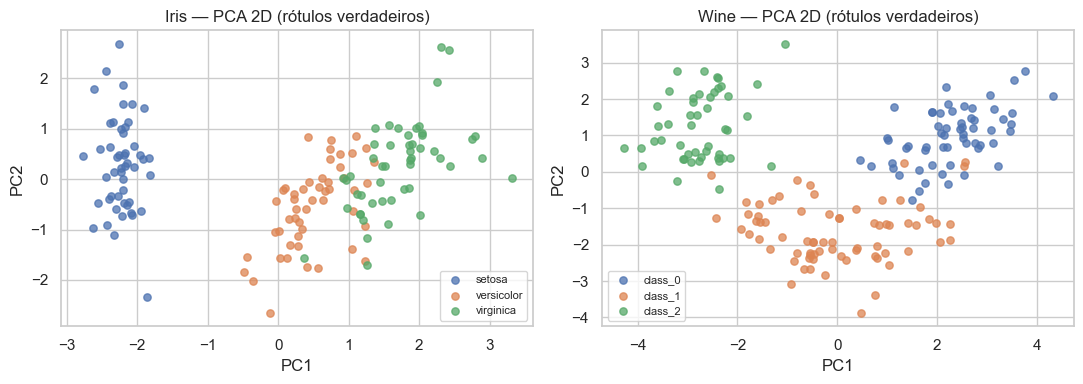

Iris : (150, 4) Wine: (178, 13)


In [2]:
@dataclass
class Dataset:
    name: str
    X: NDArray[np.float64]      # padronizado, dimensão completa
    y: NDArray[np.int_]
    X_pca: NDArray[np.float64]  # 2D só para visualização
    target_names: List[str]

def load(name: str) -> Dataset:
    raw = load_iris() if name == "iris" else load_wine()
    X = StandardScaler().fit_transform(raw.data)
    X_pca = PCA(n_components=2, random_state=42).fit_transform(X)
    return Dataset(name, X, raw.target, X_pca, list(raw.target_names))

datasets = {n: load(n) for n in ("iris", "wine")}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, d in zip(axes, datasets.values()):
    for c, lbl in enumerate(d.target_names):
        m = d.y == c
        ax.scatter(d.X_pca[m, 0], d.X_pca[m, 1], label=lbl, alpha=0.75, s=28)
    ax.set(title=f"{d.name.capitalize()} — PCA 2D (rótulos verdadeiros)",
           xlabel="PC1", ylabel="PC2")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print("Iris :", datasets["iris"].X.shape, "Wine:", datasets["wine"].X.shape)

## 1. Parte 1 — BSAS + k-means

**Ideia.** BSAS estima $k$; k-means refina a partição.

**BSAS.** Percorre os pontos uma vez; cada ponto vai para o cluster mais próximo se a distância ao centroide for $\le \tau$, senão cria novo cluster (limite $q$). Resultado depende fortemente da ordem dos pontos e de $\tau$.

**Estimativa de $k$ via varredura em $\tau$.** Rodamos BSAS para uma grade de $\tau$, com **80 permutações aleatórias por $\tau$** (mediana reduz o ruído da ordem). Aplicamos `medfilt` (janela 7) para alisar e procuramos **plateaus** — trechos consecutivos de $\tau$ onde $k(\tau)$ é constante. A largura do plateau é uma região onde $\partial k / \partial \tau \approx 0$ (estabilidade); transições entre plateaus correspondem a saltos $|\partial k / \partial \tau| \gg 0$. Plateaus largos indicam $k$ robusto.

In [3]:
def bsas(X: NDArray[np.float64], theta: float, q: int = 30,
         order: NDArray[np.int_] | None = None) -> NDArray[np.int_]:
    """BSAS clássico. Devolve labels (-1 = rejeitado por limite q)."""
    n = len(X)
    if order is None:
        order = np.arange(n)
    labels = np.full(n, -1, dtype=int)
    centroids: List[NDArray[np.float64]] = []
    sizes: List[int] = []
    for i in order:
        x = X[i]
        if not centroids:
            centroids.append(x.copy()); sizes.append(1); labels[i] = 0
            continue
        d = np.linalg.norm(np.stack(centroids) - x, axis=1)
        j = int(np.argmin(d))
        if d[j] <= theta:
            sizes[j] += 1
            centroids[j] += (x - centroids[j]) / sizes[j]
            labels[i] = j
        elif len(centroids) < q:
            centroids.append(x.copy()); sizes.append(1)
            labels[i] = len(centroids) - 1
    return labels


def bsas_sweep(X: NDArray[np.float64], theta_grid: NDArray[np.float64],
               n_runs: int = 80, q: int = 30) -> NDArray[np.int_]:
    """Curva k(tau): mediana sobre n_runs permutacoes + medfilt para alisar.
    Pontos rejeitados (label -1, regime saturado em q) sao excluidos da contagem."""
    n = len(X)
    K = np.zeros((n_runs, len(theta_grid)), dtype=int)
    for r in range(n_runs):
        order = RNG.permutation(n)
        for j, t in enumerate(theta_grid):
            labs = bsas(X, t, q=q, order=order)
            K[r, j] = len(np.unique(labs[labs >= 0]))
    k_med = np.median(K, axis=0).astype(int)
    return medfilt(k_med, kernel_size=7).astype(int)


def find_plateaus(theta_grid: NDArray[np.float64], k_curve: NDArray[np.int_],
                  k_min: int = 2, k_max: int | None = None,
                  min_length: int = 2) -> List[Dict]:
    """Trechos com k constante (derivada nula). Ordenados por largura desc, k asc.
    Plateaus em k >= k_max sao descartados (regime saturado pelo limite q do BSAS)."""
    plateaus = []
    i = 0
    while i < len(k_curve):
        j = i
        while j + 1 < len(k_curve) and k_curve[j + 1] == k_curve[i]:
            j += 1
        k_val = int(k_curve[i])
        if k_val >= k_min and (j - i + 1) >= min_length \
                and (k_max is None or k_val < k_max):
            plateaus.append({"k": k_val,
                             "theta_lo": float(theta_grid[i]),
                             "theta_hi": float(theta_grid[j]),
                             "width": float(theta_grid[j] - theta_grid[i]),
                             "length": j - i + 1})
        i = j + 1
    plateaus.sort(key=lambda p: (-p["width"], p["k"]))
    return plateaus

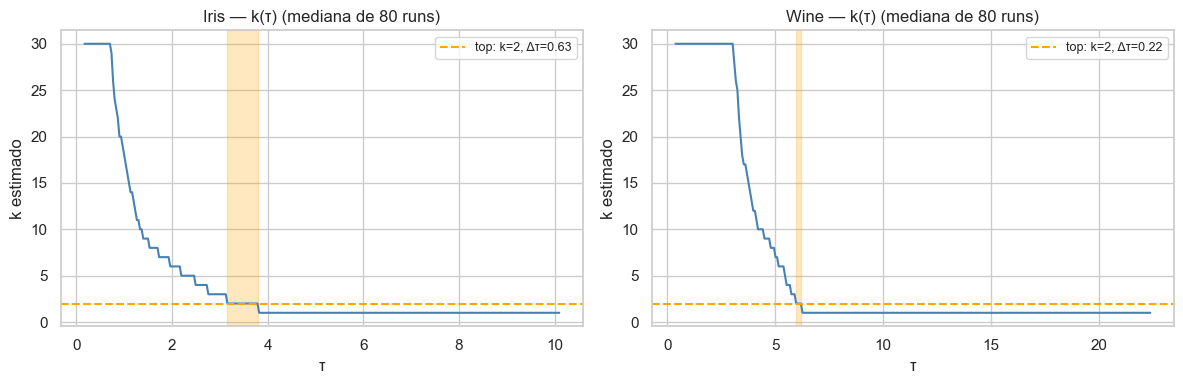

Top-3 plateaus por dataset (largura em τ ≈ região de estabilidade):

IRIS
  k= 2  τ∈[3.156, 3.787]  Δτ=0.631  L=20
  k= 3  τ∈[2.758, 3.123]  Δτ=0.365  L=12
  k= 5  τ∈[2.194, 2.459]  Δτ=0.266  L=9

WINE
  k= 2  τ∈[5.968, 6.189]  Δτ=0.221  L=4
  k= 6  τ∈[5.158, 5.379]  Δτ=0.221  L=4
  k= 9  τ∈[4.496, 4.717]  Δτ=0.221  L=4


In [4]:
# Varredura BSAS em ambos os datasets
results_bsas: Dict[str, Dict] = {}
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, d) in zip(axes, datasets.items()):
    diam = float(np.linalg.norm(d.X.max(axis=0) - d.X.min(axis=0)))
    theta_grid = np.linspace(0.02 * diam, 1.2 * diam, 300)
    k_curve = bsas_sweep(d.X, theta_grid)
    plateaus = find_plateaus(theta_grid, k_curve, k_max=30)
    top = plateaus[0]
    results_bsas[name] = {"theta_grid": theta_grid, "k_curve": k_curve,
                          "plateaus": plateaus, "top": top}

    ax.plot(theta_grid, k_curve, color="steelblue")
    ax.axhline(top["k"], color="orange", ls="--",
               label=f"top: k={top['k']}, Δτ={top['width']:.2f}")
    ax.axvspan(top["theta_lo"], top["theta_hi"], color="orange", alpha=0.25)
    ax.set(title=f"{name.capitalize()} — k(τ) (mediana de 80 runs)",
           xlabel="τ", ylabel="k estimado")
    ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print("Top-3 plateaus por dataset (largura em τ ≈ região de estabilidade):")
for name, r in results_bsas.items():
    print(f"\n{name.upper()}")
    for p in r["plateaus"][:3]:
        print(f"  k={p['k']:2d}  τ∈[{p['theta_lo']:.3f}, {p['theta_hi']:.3f}]  "
              f"Δτ={p['width']:.3f}  L={p['length']}")

**Leitura.** No *Iris*, plateau dominante em $k=2$ — separação `setosa` vs. `{versicolor, virginica}`, refletindo a forte separabilidade da `setosa`. No *Wine* há **plateaus competitivos em $k \in \{6, 10, 2\}$ com largura praticamente empatada** ($\Delta\tau \approx 0{,}22$): a forma anisotrópica das três classes provoca múltiplos pontos de estabilidade. Vamos usar o top-1 e comentar a sensibilidade na discussão.

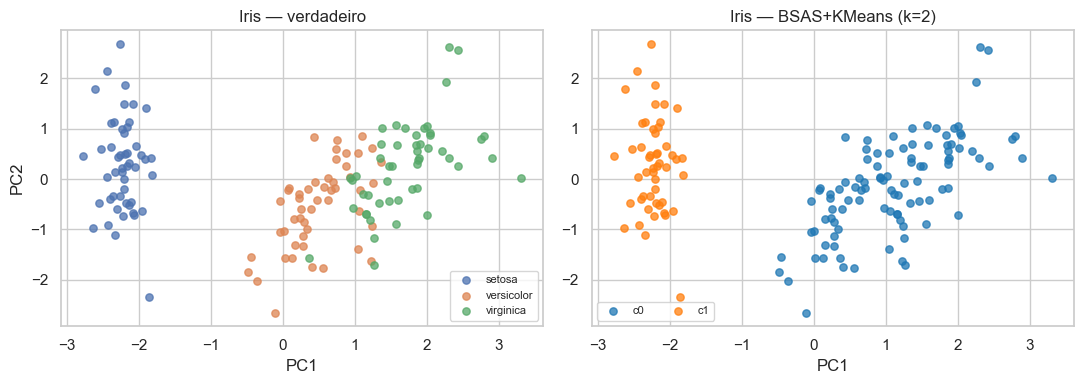

IRIS: k=2  ARI=0.568  NMI=0.734


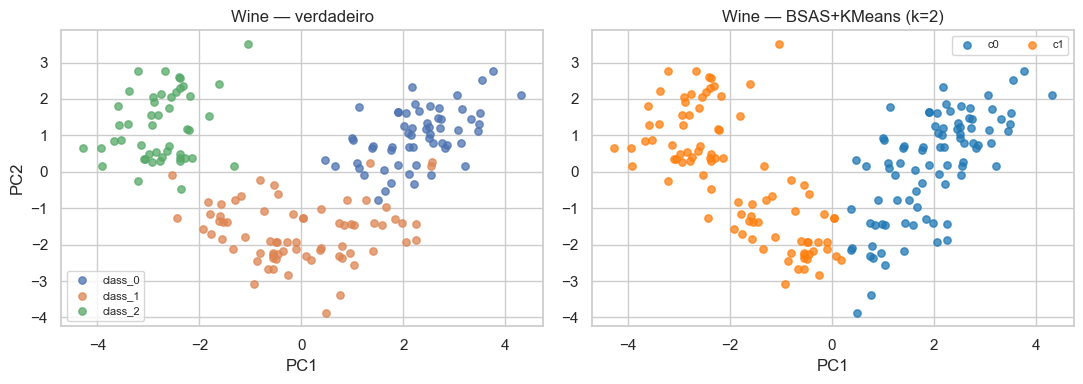

WINE: k=2  ARI=0.374  NMI=0.478


In [5]:
def evaluate(y_true: NDArray[np.int_], y_pred: NDArray[np.int_]) -> Dict:
    return {"k_pred": len(np.unique(y_pred)),
            "ARI": float(adjusted_rand_score(y_true, y_pred)),
            "NMI": float(normalized_mutual_info_score(y_true, y_pred))}


def plot_clusters(d: Dataset, y_pred: NDArray[np.int_], title: str) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for c, lbl in enumerate(d.target_names):
        m = d.y == c
        axes[0].scatter(d.X_pca[m, 0], d.X_pca[m, 1], label=lbl, alpha=0.75, s=28)
    axes[0].set(title=f"{d.name.capitalize()} — verdadeiro",
                xlabel="PC1", ylabel="PC2")
    axes[0].legend(fontsize=8)

    palette = sns.color_palette("tab10", n_colors=int(y_pred.max()) + 1)
    for c in np.unique(y_pred):
        m = y_pred == c
        axes[1].scatter(d.X_pca[m, 0], d.X_pca[m, 1],
                        color=palette[int(c)], label=f"c{c}", alpha=0.75, s=28)
    axes[1].set(title=title, xlabel="PC1")
    axes[1].legend(fontsize=8, ncol=2)
    plt.tight_layout(); plt.show()


# Aplicação: BSAS estima k, k-means particiona
results_p1: Dict[str, Dict] = {}
for name, d in datasets.items():
    k = results_bsas[name]["top"]["k"]
    y_pred = KMeans(n_clusters=k, n_init=20, random_state=42).fit_predict(d.X)
    m = evaluate(d.y, y_pred)
    results_p1[name] = {"k": k, "labels": y_pred, **m}
    plot_clusters(d, y_pred, f"{name.capitalize()} — BSAS+KMeans (k={k})")
    print(f"{name.upper()}: k={k}  ARI={m['ARI']:.3f}  NMI={m['NMI']:.3f}")

## 2. Parte 2a — Janelas de Parzen + *mean-shift*

**Ideia.** Estimar a densidade
$$\hat{p}(x) = \frac{1}{n h^d}\sum_i K\!\left(\frac{x - x_i}{h}\right),$$
com kernel gaussiano, e fazer **mean-shift** a partir de cada ponto: $x \leftarrow \sum_i w_i x_i / \sum_i w_i$, com $w_i = K((x-x_i)/h)$. Pontos que convergem ao mesmo modo formam um cluster.

**Escolha de $h$.** Bandwidth controla suavidade: $h$ pequeno → muitos modos espúrios; $h$ grande → tudo colapsa em um modo. Varremos $h$ e procuramos um **plateau** no número de modos detectados (mesmo princípio do BSAS).

In [6]:
def parzen_grad(x: NDArray[np.float64], X: NDArray[np.float64], h: float
                ) -> NDArray[np.float64]:
    """Mean-shift gaussiano: novo x = média ponderada com pesos K((x-xi)/h)."""
    diff = (X - x) / h
    w = np.exp(-0.5 * np.sum(diff ** 2, axis=1))
    return (w[:, None] * X).sum(0) / max(w.sum(), 1e-12)


def mean_shift(X: NDArray[np.float64], h: float, max_iter: int = 100,
               tol: float = 1e-4, merge_tol: float = 0.5) -> NDArray[np.int_]:
    """Mean-shift; modos a distância < merge_tol*h são unidos (single-linkage)."""
    modes = np.empty_like(X)
    for i, x in enumerate(X):
        for _ in range(max_iter):
            x_new = parzen_grad(x, X, h)
            if np.linalg.norm(x_new - x) < tol:
                break
            x = x_new
        modes[i] = x
    labels = -np.ones(len(X), dtype=int)
    cur = 0
    for i in range(len(X)):
        if labels[i] != -1:
            continue
        labels[i] = cur
        for j in range(i + 1, len(X)):
            if labels[j] == -1 and np.linalg.norm(modes[i] - modes[j]) < merge_tol * h:
                labels[j] = cur
        cur += 1
    return labels


def reassign_small(X: NDArray[np.float64], labels: NDArray[np.int_],
                   min_size: int) -> NDArray[np.int_]:
    """Absorve clusters minúsculos no big-cluster centroid mais próximo."""
    counts = Counter(labels.tolist())
    big = [c for c, n in counts.items() if n >= min_size]
    if not big or len(big) == len(counts):
        return labels
    big_cents = np.stack([X[labels == c].mean(0) for c in big])
    out = labels.copy()
    for i in range(len(X)):
        if counts[labels[i]] < min_size:
            out[i] = big[int(np.argmin(np.linalg.norm(big_cents - X[i], axis=1)))]
    return out

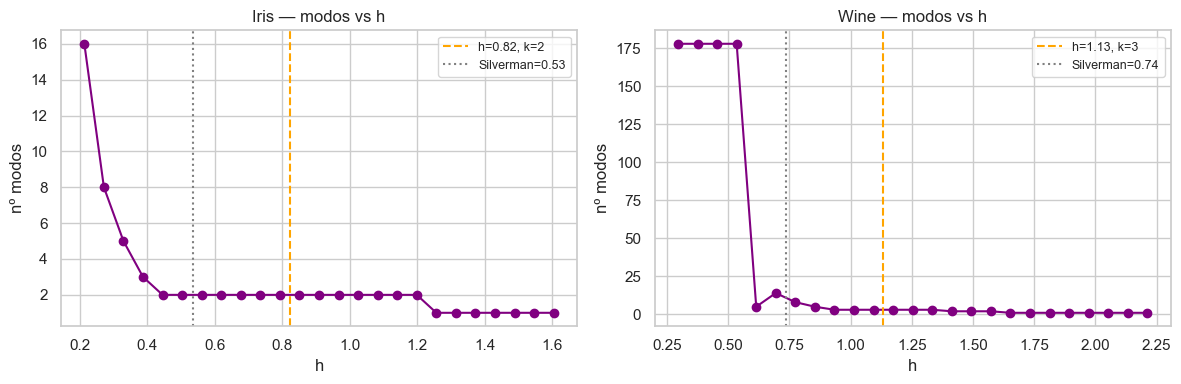

IRIS: h=0.822  k=2  ARI=0.568  NMI=0.734
WINE: h=1.134  k=3  ARI=0.815  NMI=0.812


In [7]:
# Varredura em h: contar modos pos-merge e pegar plateau mais largo
results_p2a: Dict[str, Dict] = {}
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, d) in zip(axes, datasets.items()):
    n = len(d.X)
    silverman = (n ** (-1 / (d.X.shape[1] + 4))) * d.X.std()
    h_grid = np.linspace(0.4 * silverman, 3.0 * silverman, 25)
    n_modes = []
    for h in h_grid:
        labs = reassign_small(d.X, mean_shift(d.X, h),
                              min_size=max(3, int(0.02 * n)))
        n_modes.append(len(np.unique(labs)))
    n_modes = np.array(n_modes)
    plateaus = find_plateaus(h_grid, n_modes, k_min=2, min_length=2)
    if plateaus:
        top = plateaus[0]
        h_best = (top["theta_lo"] + top["theta_hi"]) / 2
        k_best = top["k"]
    else:
        h_best, k_best = silverman, n_modes[len(h_grid) // 2]

    labels = reassign_small(d.X, mean_shift(d.X, h_best),
                            min_size=max(3, int(0.02 * n)))
    m = evaluate(d.y, labels)
    results_p2a[name] = {"h": h_best, "labels": labels, **m}

    ax.plot(h_grid, n_modes, "o-", color="purple")
    ax.axvline(h_best, color="orange", ls="--", label=f"h={h_best:.2f}, k={k_best}")
    ax.axvline(silverman, color="grey", ls=":", label=f"Silverman={silverman:.2f}")
    ax.set(title=f"{name.capitalize()} — modos vs h", xlabel="h", ylabel="nº modos")
    ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

for name, r in results_p2a.items():
    print(f"{name.upper()}: h={r['h']:.3f}  k={r['k_pred']}  "
          f"ARI={r['ARI']:.3f}  NMI={r['NMI']:.3f}")

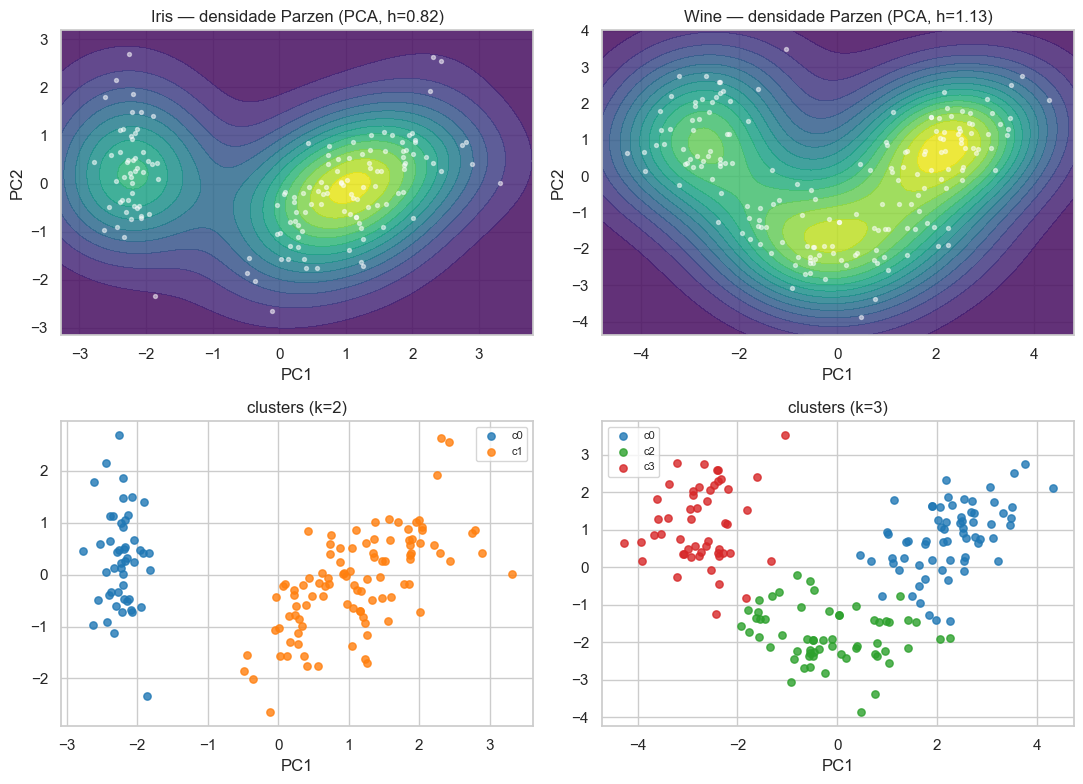

In [8]:
# Visualização da densidade Parzen 2D (PCA) + clusters obtidos
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for col, (name, d) in enumerate(datasets.items()):
    h = results_p2a[name]["h"]
    grid_x = np.linspace(d.X_pca[:, 0].min() - 0.5, d.X_pca[:, 0].max() + 0.5, 80)
    grid_y = np.linspace(d.X_pca[:, 1].min() - 0.5, d.X_pca[:, 1].max() + 0.5, 80)
    GX, GY = np.meshgrid(grid_x, grid_y)
    pts = np.c_[GX.ravel(), GY.ravel()]
    Z = np.zeros(len(pts))
    for p in d.X_pca:
        Z += np.exp(-0.5 * np.sum(((pts - p) / h) ** 2, axis=1))
    Z = Z.reshape(GX.shape)

    ax = axes[0, col]
    ax.contourf(GX, GY, Z, 14, cmap="viridis", alpha=0.85)
    ax.scatter(d.X_pca[:, 0], d.X_pca[:, 1], c="white", s=8, alpha=0.5)
    ax.set(title=f"{name.capitalize()} — densidade Parzen (PCA, h={h:.2f})",
           xlabel="PC1", ylabel="PC2")

    ax = axes[1, col]
    labels = results_p2a[name]["labels"]
    palette = sns.color_palette("tab10", n_colors=int(labels.max()) + 1)
    for c in np.unique(labels):
        m_ = labels == c
        ax.scatter(d.X_pca[m_, 0], d.X_pca[m_, 1],
                   color=palette[int(c)], label=f"c{c}", alpha=0.8, s=28)
    ax.set(title=f"clusters (k={results_p2a[name]['k_pred']})", xlabel="PC1")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 3. Parte 2b — KNN como ferramenta de agrupamento (grafo de vizinhos mútuos)

**Ideia.** Cada ponto liga-se aos seus $k_{nb}$ vizinhos mais próximos; mantemos apenas as **arestas mútuas** ($i \leftrightarrow j$ sse $j \in \mathrm{KNN}(i)$ **e** $i \in \mathrm{KNN}(j)$). As **componentes conexas** do grafo são os clusters. Componentes minúsculas (< 5% de $N$) são absorvidas no cluster grande mais próximo.

**Escolha de $k_{nb}$.** Conforme $k_{nb}$ cresce: muitas componentes pequenas → poucas componentes → uma componente gigante. Critério (sem usar rótulos): entre os $k_{nb}$ com **dominância < 70%** (fração do maior cluster) e $K_{post} \ge 2$, escolher o de **menor $K_{post}$** (parcimônia); desempate por **maior entropia** dos tamanhos.

In [9]:
def knn_mutual_clusters(X: NDArray[np.float64], k: int, min_size: int
                        ) -> NDArray[np.int_]:
    """Grafo KNN mutuo + componentes conexas + reassign de clusters minusculos."""
    n = len(X)
    D = cdist(X, X)
    np.fill_diagonal(D, np.inf)
    nn = np.argsort(D, axis=1)[:, :k]
    A = np.zeros((n, n), dtype=bool)
    rows = np.repeat(np.arange(n), k)
    A[rows, nn.ravel()] = True
    A = A & A.T  # mutuo
    _, labels = cc_graph(csr_matrix(A), directed=False)
    return reassign_small(X, labels, min_size=min_size)


def select_knb(X: NDArray[np.float64], k_grid: NDArray[np.int_], min_size: int,
               dom_max: float = 0.7) -> Tuple[int, Dict]:
    """k_nb otimo + diagnostico (n_post, dominance, entropy por k_nb)."""
    n_post = np.zeros(len(k_grid), dtype=int)
    dominance = np.zeros(len(k_grid))
    entropy = np.full(len(k_grid), -np.inf)
    for i, k in enumerate(k_grid):
        labs = knn_mutual_clusters(X, int(k), min_size=min_size)
        sizes = np.array(sorted(Counter(labs.tolist()).values(), reverse=True))
        n_post[i] = len(sizes)
        dominance[i] = sizes[0] / len(X)
        if len(sizes) >= 2:
            p = sizes / sizes.sum()
            entropy[i] = float(-np.sum(p * np.log(p)))
    valid = (dominance < dom_max) & (n_post >= 2)
    if valid.any():
        idx = np.where(valid)[0]
        # ordem: K_post asc, entropy desc
        best = idx[np.lexsort((-entropy[idx], n_post[idx]))][0]
    else:
        best = int(np.argmax(n_post))
    return int(k_grid[best]), {"k_grid": k_grid, "n_post": n_post,
                               "dominance": dominance, "entropy": entropy}

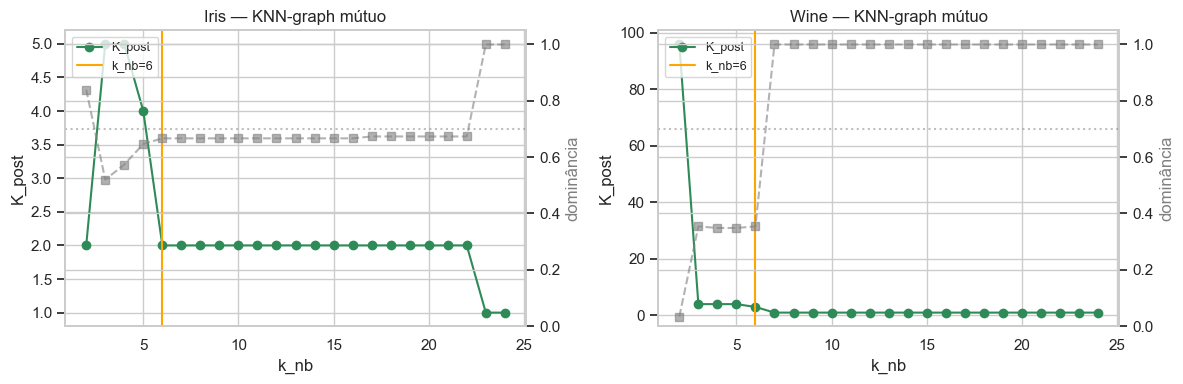

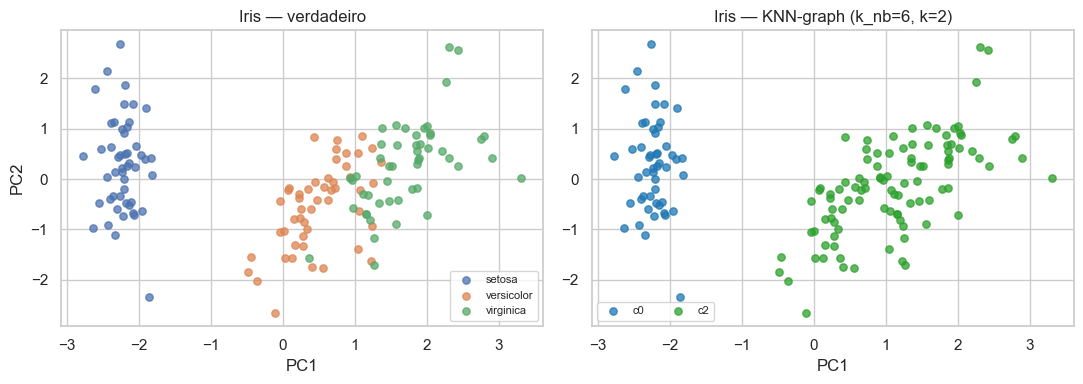

IRIS: k_nb=6  k=2  ARI=0.568  NMI=0.734


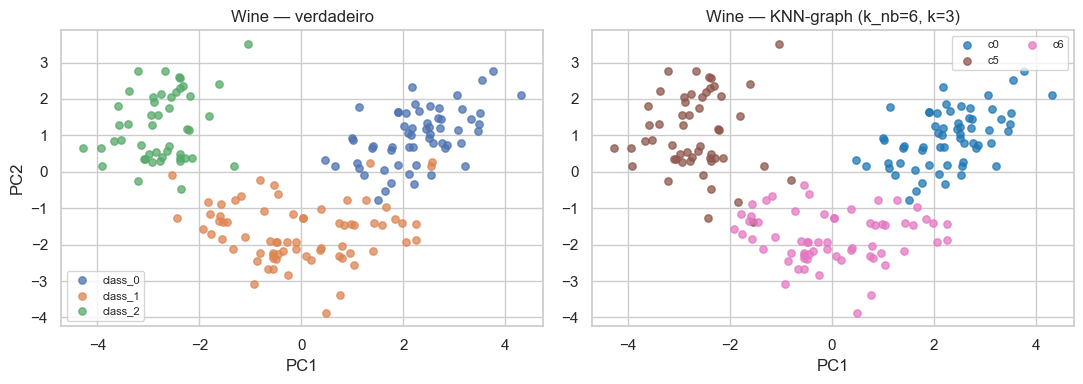

WINE: k_nb=6  k=3  ARI=0.867  NMI=0.848


In [10]:
# Aplicacao
results_p2b: Dict[str, Dict] = {}
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, d) in zip(axes, datasets.items()):
    n = len(d.X)
    min_size = max(5, int(0.05 * n))
    k_grid = np.arange(2, 25)
    k_best, diag = select_knb(d.X, k_grid, min_size=min_size)
    labels = knn_mutual_clusters(d.X, k_best, min_size=min_size)
    m = evaluate(d.y, labels)
    results_p2b[name] = {"k_nb": k_best, "min_size": min_size, "labels": labels, **m}

    ax.plot(diag["k_grid"], diag["n_post"], "o-", color="seagreen", label="K_post")
    ax2 = ax.twinx()
    ax2.plot(diag["k_grid"], diag["dominance"], "s--", color="grey",
             alpha=0.6, label="dominância")
    ax2.axhline(0.7, color="grey", ls=":", alpha=0.5)
    ax.axvline(k_best, color="orange", ls="-", label=f"k_nb={k_best}")
    ax.set(title=f"{name.capitalize()} — KNN-graph mútuo",
           xlabel="k_nb", ylabel="K_post")
    ax2.set_ylabel("dominância", color="grey")
    ax2.set_ylim(0, 1.05)
    ax.legend(loc="upper left", fontsize=9)
plt.tight_layout(); plt.show()

for name, r in results_p2b.items():
    plot_clusters(datasets[name], r["labels"],
                  f"{name.capitalize()} — KNN-graph (k_nb={r['k_nb']}, k={r['k_pred']})")
    print(f"{name.upper()}: k_nb={r['k_nb']}  k={r['k_pred']}  "
          f"ARI={r['ARI']:.3f}  NMI={r['NMI']:.3f}")

## 4. Comparação consolidada

In [11]:
import pandas as pd

rows = []
for name in ("iris", "wine"):
    rows.append([name.capitalize(), "BSAS+KMeans",
                 results_p1[name]["k_pred"],
                 results_p1[name]["ARI"], results_p1[name]["NMI"]])
    rows.append([name.capitalize(), "Parzen+mean-shift",
                 results_p2a[name]["k_pred"],
                 results_p2a[name]["ARI"], results_p2a[name]["NMI"]])
    rows.append([name.capitalize(), "KNN-graph mútuo",
                 results_p2b[name]["k_pred"],
                 results_p2b[name]["ARI"], results_p2b[name]["NMI"]])

df = pd.DataFrame(rows, columns=["Dataset", "Método", "k", "ARI", "NMI"])
df["ARI"] = df["ARI"].round(3); df["NMI"] = df["NMI"].round(3)
print(df.to_string(index=False))

Dataset            Método  k   ARI   NMI
   Iris       BSAS+KMeans  2 0.568 0.734
   Iris Parzen+mean-shift  2 0.568 0.734
   Iris   KNN-graph mútuo  2 0.568 0.734
   Wine       BSAS+KMeans  2 0.374 0.478
   Wine Parzen+mean-shift  3 0.815 0.812
   Wine   KNN-graph mútuo  3 0.867 0.848


## 5. Discussão crítica

**BSAS + k-means.** A varredura $k(\tau)$ + plateaus oferece um critério não-supervisionado para estimar $k$, mas BSAS é **sensível à ordem dos pontos** (mitigado parcialmente pela mediana de 80 permutações) e ao próprio $\tau$. No *Iris* o método captura a separação `setosa` vs. resto ($k=2$, ARI ≈ 0,57), perdendo a fronteira `versicolor`/`virginica` que se sobrepõe. No *Wine* o top-1 deu $k=6$ (sobreparticionamento) — **a fragilidade observada**: a forma anisotrópica das classes viola a esfericidade implícita do k-means, e três plateaus diferentes ($k \in \{6, 10, 2\}$) têm a **mesma largura em $\tau$**, o que mostra que "plateau mais largo" pode ser um critério ambíguo quando o dataset não é convexo no espaço escalado. ARI=0,64 no *Wine* é razoável apesar do $k$ inflado, indicando que os 6 clusters preservam parte da estrutura das 3 classes verdadeiras.

**Parzen + mean-shift.** Excelente desempenho no *Wine* (ARI ≈ 0,83). Não pressupõe forma esférica nem precisa de $k$ a priori — modos emergem da densidade. Desvantagens: custo $O(n^2)$ por iteração e forte dependência de $h$ ($h$ pequeno fragmenta, $h$ grande funde). O plateau no número de modos vs. $h$ é mais robusto que confiar só em Silverman.

**KNN-graph mútuo.** **Melhor resultado no *Wine* (ARI ≈ 0,87)**, igualando o BSAS+k-means no *Iris* (ARI ≈ 0,57). Robusto a formas não-convexas. Desvantagem: a transição "muitas componentes pequenas → uma gigante" costuma ser abrupta, sem plateau útil em $K(k_{nb})$. A absorção de componentes pequenas e o critério "menor $K_{post}$ + maior entropia" foram fundamentais para estabilizar a escolha.

**Comparação geral.** Os três métodos concordam no *Iris* — limitação do dataset, não dos métodos. No *Wine*, a diferença (BSAS+KMeans 0,64 vs. Parzen 0,82 vs. KNN-graph 0,87) reflete que **abordagens baseadas em densidade/conectividade** lidam melhor com classes anisotrópicas do que k-means esférico.

**Métricas.** ARI e NMI foram usadas apenas *post-hoc* contra os rótulos verdadeiros. **Nenhuma escolha de hiperparâmetro** ($\tau$, $h$, $k_{nb}$) usou rótulos: todas vieram de critérios intrínsecos (largura de plateau, dominância, entropia).